# Проект исследования данных игрового приложения

Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.

Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.

Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

У нас есть следующие датасеты:

- problem1-reg_data.csv – данные о времени регистрации

- problem1-auth_data.csv – данные о времени захода пользователей в игру

- problem2.csv – результаты A/B теста

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

## 1. Retention

## 1.1 Подготовка данных
начнем с регистраций

In [2]:
reg = pd.read_csv('problem1-reg_data.csv', sep =';')  #работу проводил с данными в той же папке, но в условии просили использовать ссылку с shared, меняю
reg

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5
...,...,...
999995,1600874034,1110618
999996,1600874086,1110619
999997,1600874139,1110620
999998,1600874191,1110621


In [3]:
reg.info() 
# посмотрим на данные и увидим что тип данных один - int64, нулевых значений нет
#reg_ts uid - время регистрации в неудобном для восприятия формате и id юзера соответственно

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB


In [4]:
reg['reg_ts'] = pd.to_datetime(reg['reg_ts'], unit='s')
reg #теперь даты доступны для восприятия

,reg_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,2000-01-13 22:27:27,3
3,2000-05-28 14:19:01,4
4,2000-09-16 11:21:53,5
...,...,...
999995,2020-09-23 15:13:54,1110618
999996,2020-09-23 15:14:46,1110619
999997,2020-09-23 15:15:39,1110620
999998,2020-09-23 15:16:31,1110621


In [5]:
reg.uid.duplicated().sum() #регистрации однократны что разумно

0

In [6]:
reg['reg_ts'].describe()

/tmp/ipykernel_323/1327853110.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  reg['reg_ts'].describe()


count                 1000000
unique                1000000
top       2020-09-23 14:43:15
freq                        1
first     1998-11-18 09:43:43
last      2020-09-23 15:17:24
Name: reg_ts, dtype: object

In [7]:
#Регистрации имеют данные за 98 год. Похоже на ошибку.

In [8]:
reg_by_year = reg['reg_ts'].dt.year.value_counts(normalize=True).reset_index().rename(columns={'index':'year', 'reg_ts':'proportion'})
reg_by_year.head(10)

,year,proportion
0,2020,0.354963
1,2019,0.291102
2,2018,0.159729
3,2017,0.087645
4,2016,0.048187
5,2015,0.026344
6,2014,0.014455
7,2013,0.007932
8,2012,0.004361
9,2011,0.002385


In [9]:
reg_by_year[reg_by_year['proportion'] >0.001] 
#каждый год доля регистраций до 2014 года меньше 1%. 
#наверное не нужно брать совсем старые данные. 
#возьму с 2013 го - запустил тогда первую мобильную игру. попробую так тестово

,year,proportion
0,2020,0.354963
1,2019,0.291102
2,2018,0.159729
3,2017,0.087645
4,2016,0.048187
5,2015,0.026344
6,2014,0.014455
7,2013,0.007932
8,2012,0.004361
9,2011,0.002385


In [10]:
reg_13 = reg[reg['reg_ts'] > '2013']
reg_13.reset_index(inplace=True, drop=True)

In [11]:
reg_13

,reg_ts,uid
0,2013-01-01 00:37:41,10695
1,2013-01-01 02:08:28,10696
2,2013-01-01 03:39:15,10697
3,2013-01-01 05:10:01,10698
4,2013-01-01 06:40:47,10699
...,...,...
990352,2020-09-23 15:13:54,1110618
990353,2020-09-23 15:14:46,1110619
990354,2020-09-23 15:15:39,1110620
990355,2020-09-23 15:16:31,1110621


In [12]:
reg_13['reg_ts'].describe(datetime_is_numeric=True)

count                           990357
mean     2019-02-20 23:37:36.450259968
min                2013-01-01 00:37:41
25%                2018-06-20 22:09:14
50%                2019-08-04 22:39:31
75%                2020-04-03 15:19:01
max                2020-09-23 15:17:24
Name: reg_ts, dtype: object

In [13]:
reg_13['reg_ts'].count()/reg['reg_ts'].count()
#99% данных на месте, мы убрали меньше 1% строк

0.990357

Далее стоит посмотреть на id

In [14]:
reg_13['uid']
#цифровой тип данных - обычно их не используют в арифметике, преобразуем в строки

0           10695
1           10696
2           10697
3           10698
4           10699
           ...   
990352    1110618
990353    1110619
990354    1110620
990355    1110621
990356    1110622
Name: uid, Length: 990357, dtype: int64

In [15]:
reg_13['uid'] = reg_13['uid'].astype('str')

/tmp/ipykernel_323/409577701.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg_13['uid'] = reg_13['uid'].astype('str')


In [16]:
reg_13.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990357 entries, 0 to 990356
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   reg_ts  990357 non-null  datetime64[ns]
 1   uid     990357 non-null  object        
dtypes: datetime64[ns](1), object(1)
memory usage: 15.1+ MB


Поработаем с аутентификациями пользователей аналогичным образом

In [17]:
auth = pd.read_csv('problem1-auth_data.csv', sep =';')
auth

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2
...,...,...
9601008,1600874034,1110618
9601009,1600874086,1110619
9601010,1600874139,1110620
9601011,1600874191,1110621


In [18]:
auth.isna().sum()

auth_ts    0
uid        0
dtype: int64

In [19]:
auth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB


In [20]:
auth['auth_ts'] = pd.to_datetime(auth['auth_ts'], unit='s')


In [21]:
auth['auth_ts']

0         1998-11-18 09:43:43
1         1999-07-22 22:38:09
2         1999-07-25 16:46:46
3         1999-07-31 03:50:15
4         1999-08-05 17:49:39
                  ...        
9601008   2020-09-23 15:13:54
9601009   2020-09-23 15:14:46
9601010   2020-09-23 15:15:39
9601011   2020-09-23 15:16:31
9601012   2020-09-23 15:17:24
Name: auth_ts, Length: 9601013, dtype: datetime64[ns]

In [22]:
auth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype         
---  ------   -----         
 0   auth_ts  datetime64[ns]
 1   uid      int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 146.5 MB


In [23]:
auth['auth_ts'].describe(datetime_is_numeric=True)

count                          9601013
mean     2019-01-29 16:12:06.254851584
min                1998-11-18 09:43:43
25%                2018-06-07 12:40:47
50%                2019-07-31 12:43:16
75%                2020-04-02 10:25:21
max                2020-09-23 15:17:24
Name: auth_ts, dtype: object

In [24]:
auth[auth['auth_ts'] > '2013']

,auth_ts,uid
82462,2013-01-01 00:09:10,555
82463,2013-01-01 00:18:55,3317
82464,2013-01-01 00:36:31,3062
82465,2013-01-01 00:37:41,10695
82466,2013-01-01 00:38:27,6223
...,...,...
9601008,2020-09-23 15:13:54,1110618
9601009,2020-09-23 15:14:46,1110619
9601010,2020-09-23 15:15:39,1110620
9601011,2020-09-23 15:16:31,1110621


In [25]:
auth_13 = auth[auth['auth_ts'] > '2013']

In [26]:
1-auth_13.auth_ts.count()/auth.auth_ts.count()

0.008588885360326093

отсечено порядка 0,8% строк

In [27]:
auth_13['uid'] = auth_13['uid'].astype('str') #kernel не вывозил прошлый вариант

/tmp/ipykernel_323/1924378287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  auth_13['uid'] = auth_13['uid'].astype('str') #kernel не вывозил прошлый вариант


In [28]:
auth_13.info() #тип поменялся

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9518551 entries, 82462 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype         
---  ------   -----         
 0   auth_ts  datetime64[ns]
 1   uid      object        
dtypes: datetime64[ns](1), object(1)
memory usage: 217.9+ MB


Посмотрим на статистику захода пользователей

In [29]:
auth_stat = auth_13.groupby('uid', as_index=False).agg({'auth_ts': 'count'}) \
    .rename(columns={'auth_ts':'visits'}).sort_values('visits', ascending=False)

In [30]:
auth_stat

,uid,visits
803619,8110,742
561630,5665,738
662771,6687,736
156656,158,735
447623,4515,734
...,...,...
374252,377633,1
374253,377634,1
374254,377635,1
374255,377637,1


In [31]:
auth_stat['visits'].describe()

count    990873.000000
mean          9.606227
std          46.138539
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         742.000000
Name: visits, dtype: float64

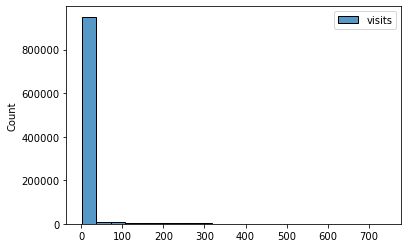

In [32]:
sns.histplot(auth_stat) 
#огромное число юзеров >75% зашли в игру ровно 1 раз 
#- скорее всего боты или разочаровавшиеся юзеры - в этом нужно разобраться

In [33]:
more_than_once = auth_stat[auth_stat['visits'] >1]
#236 тысяч пользователей зашли больше одного раза из 990 тыс

In [34]:
more_than_once['uid'].nunique() / auth_stat['uid'].nunique() 
#23,8% играли больше одного раза

0.23874906269521926

## 1.2 Retention

In [35]:
reg = pd.read_csv('problem1-reg_data.csv', sep =';') 


In [ ]:
auth = pd.read_csv('problem1-auth_data.csv', sep =';')

In [ ]:
reg['reg_ts'] = pd.to_datetime(reg['reg_ts'], unit='s')


In [ ]:
auth['auth_ts'] = pd.to_datetime(auth['auth_ts'], unit='s')


In [ ]:
#kernel ломается(( хотя казалось бы.
#df = auth.merge(reg, how='left', on='uid')
# построю тогда для малой выборки с 13 по 15-й год. 
reg = reg[reg['reg_ts'] > '2013']
auth = auth[auth['auth_ts'] > '2013']

In [ ]:

reg['uid'] = reg['uid'].astype('str')
auth['uid'] = auth['uid'].astype('str')
a = reg[reg['reg_ts'] < '2015']
b = auth[auth['auth_ts'] < '2015']


In [ ]:
df = a.merge(b, how='left', on = 'uid') 

In [ ]:
df

In [ ]:
def retention(df):

    # выделяем только даты
    df['date_reg'] = df.reg_ts.dt.date
    df['date_auth'] = df.auth_ts.dt.date
    
    #смотрим число дней между регистрацией и входом
    df['days'] = df['date_auth'] - df['date_reg']
    
    # агрегируем по uid
    cohorts = df.groupby(['date_reg', 'days'], as_index=False) \
                  .agg({'uid': 'nunique'})  

    cohorts_pivot = cohorts.pivot(index='date_reg', columns='days', values='uid')
    
    retention = pd.DataFrame()  
    for i in range(cohorts_pivot.shape[0]):  
        a = cohorts_pivot.iloc[i, 0]  
        temp = cohorts_pivot.iloc[i, :].divide(a, axis=0).round(4)   
        retention = pd.concat([retention, temp], ignore_index=True)

    return retention

In [ ]:
ret = retention(df)
ret

Трудно сделать выводы из плохих данных с 2013 по 2015 год, но увы более робастные мой компьютер не тянет(
Формально функция в наличии.. постараюсь обновить железо и доделать для портфолио

## 2. A/B тест

Задание 2
Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

In [5]:
df = pd.read_csv('problem2.csv', sep =';')

### 2.1 Исследование данных

In [6]:
df

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b
...,...,...,...
404765,404766,0,a
404766,404767,0,b
404767,404768,231,a
404768,404769,0,a


In [7]:
df.dtypes

user_id       int64
revenue       int64
testgroup    object
dtype: object

In [ ]:
'''user_id - id пользователя, число
revenue - выручка с пользователя, число
testgroup - индикатор группы, текст'''

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    404770 non-null  int64 
 1   revenue    404770 non-null  int64 
 2   testgroup  404770 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.3+ MB


In [ ]:
#нулей и пропусков нет

### 2.2 Подготовка данных

In [9]:
df.user_id.duplicated().sum() #повторов айди нет

0

In [10]:
df['user_id'] = df['user_id'].astype('str') 
df.dtypes 

user_id      object
revenue       int64
testgroup    object
dtype: object

In [11]:
groups = df.testgroup.value_counts()
groups #roughly of equal size

b    202667
a    202103
Name: testgroup, dtype: int64

In [12]:
# разбиение по группам и подсчет статистики
a = df[df['testgroup'] == 'a'].revenue.describe()
b = df[df['testgroup'] == 'b'].revenue.describe()

In [13]:
# сведение в одну таблицу
revenue_stats = pd.concat([a, b], axis=1, keys=['revenue A', 'revenue B'])

revenue_stats

,revenue A,revenue B
count,202103.000000,202667.000000
mean,25.413720,26.751287
std,920.768137,287.324162
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,37433.000000,4000.000000


In [14]:
# mean revenue B > mean revenue A но насколько это значимый результат?

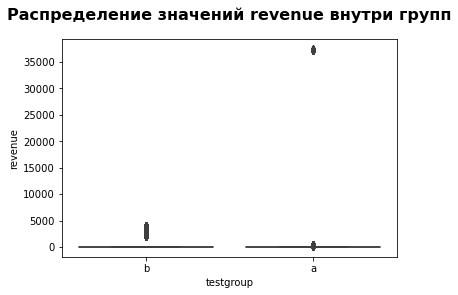

In [15]:
sns.boxplot(data=df, x='testgroup', y='revenue')
plt.title('Распределение значений revenue внутри групп', fontsize=16, fontweight='bold', pad=20)
plt.show()

посмотрим на платящих пользователей. в конце концов пользователям предлагались акции и нам нужно понять повлияли ли они на доходы.

Text(0.5, 1.0, 'Распределение выручки внутри групп A и B')

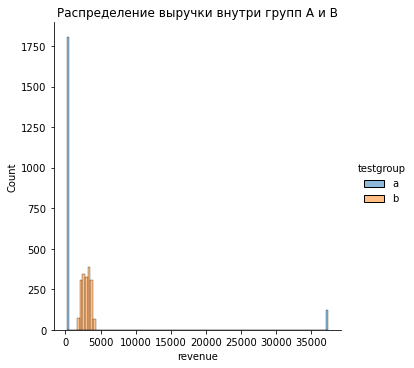

In [16]:
sns.displot(data=df[df['revenue'] > 0], x='revenue', hue='testgroup', bins=100);
plt.title('Распределение выручки внутри групп A и B')

заметен большой разброс среди групп платящих пользователей

In [17]:
# разбиение по группам и подсчет статистики
revenue_paid_stats = df[df['revenue'] > 0].groupby('testgroup')['revenue'].describe().T
revenue_paid_stats

testgroup,a,b
count,1928.000000,1805.000000
mean,2663.998444,3003.658172
std,9049.039763,572.619709
min,200.000000,2000.000000
25%,257.000000,2513.000000
50%,311.000000,3022.000000
75%,361.000000,3478.000000
max,37433.000000,4000.000000


Подробнее рассмотрим распределение значений revenue внутри групп для платящих пользователей

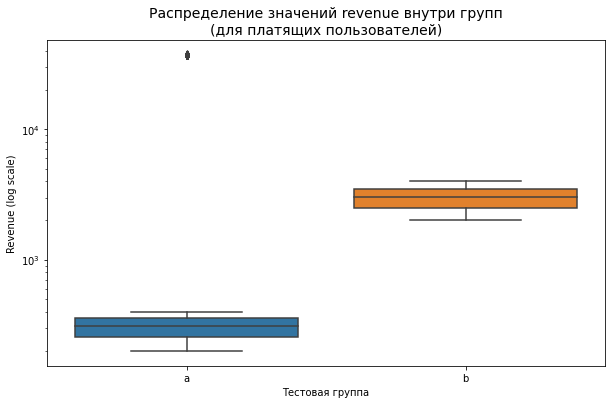

In [18]:
df_paying = df[df['revenue'] > 0]


plt.figure(figsize=(10, 6))
sns.boxplot(x='testgroup', y='revenue', data=df_paying)
plt.yscale('log') #сделал логарифмическую шкалу чтоб было хоть что-то видно


plt.title('Распределение значений revenue внутри групп\n(для платящих пользователей)', fontsize=14)

plt.xlabel('Тестовая группа')
plt.ylabel('Revenue (log scale)')

plt.show()

мы видим что в группе А много выбросов - с выручкой свыше 35000. Они сильно влияют  на средние величины и мешают анализу.


- возможно это ошибка данных - доход от них в 10-100 раз больше чем у остальных в группе А. 

- если это реальные индивиды то группы А и Б сильно отличаются и в таком случае А/Б тест может быть бессмысленно проводить на этих данных ввиду большого отличия групп.

Логично посмотреть на данные с выбросами дабы избежать ошибки в случае если ошибок все же нет, так и без них.

In [24]:
df_filt = df[df['revenue'] < 35000] #без выбросов

In [20]:
df.count() - df_filt.count() #убрали 123 юзера

user_id      123
revenue      123
testgroup    123
dtype: int64

Можно заключить что из 1928 юзеров группы контроля осталось 1805 и теперь группы равны по численности.
Учитывая, что изначально ARPU был выше в группе теста --> теперь разница только выросла в пользу группы Б

In [21]:
df_filt

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b
...,...,...,...
404765,404766,0,a
404766,404767,0,b
404767,404768,231,a
404768,404769,0,a


In [ ]:
df_filt[df_filt['testgroup'] =='a'].revenue.describe()

In [ ]:
df_filt[df_filt['testgroup'] =='b'].revenue.describe()

In [ ]:
#все еще видим большие отличия: медиана, ст. отклонение и максимальное значение отличаются в 10 раз.
#интересно если убрать 0 revenue - с минимумом будет также?

In [38]:
df_fnn = df_filt[df_filt['revenue']>0]
#оставим только платящих в группе без выбросов 
#и в оригинальном df
df_nn= df[df['revenue']>0]

In [26]:
df_nn[df_nn['testgroup'] =='a'].revenue.describe(), df_nn[df_nn['testgroup'] =='b'].revenue.describe()

(count     1928.000000
 mean      2663.998444
 std       9049.039763
 min        200.000000
 25%        257.000000
 50%        311.000000
 75%        361.000000
 max      37433.000000
 Name: revenue, dtype: float64,
 count    1805.000000
 mean     3003.658172
 std       572.619709
 min      2000.000000
 25%      2513.000000
 50%      3022.000000
 75%      3478.000000
 max      4000.000000
 Name: revenue, dtype: float64)

In [27]:
df_fnn[df_fnn['testgroup'] =='a'].revenue.describe(), df_fnn[df_fnn['testgroup'] =='b'].revenue.describe()

(count    1805.000000
 mean      302.458172
 std        57.914246
 min       200.000000
 25%       254.000000
 50%       305.000000
 75%       352.000000
 max       400.000000
 Name: revenue, dtype: float64,
 count    1805.000000
 mean     3003.658172
 std       572.619709
 min      2000.000000
 25%      2513.000000
 50%      3022.000000
 75%      3478.000000
 max      4000.000000
 Name: revenue, dtype: float64)

Построим графики для визуализации различий групп

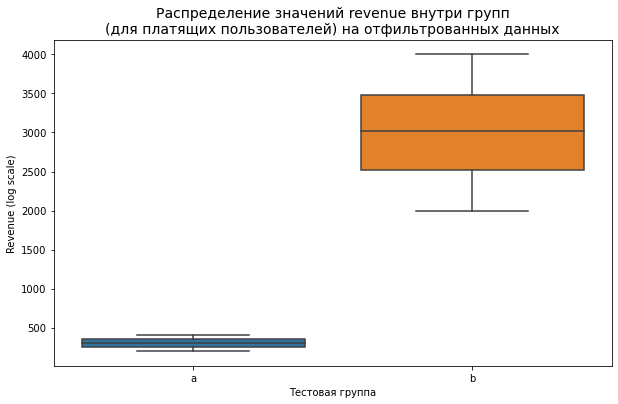

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='testgroup', y='revenue', data=df_fnn) 
#взял данные платящих и без выбросов

plt.title('Распределение значений revenue внутри групп\n(для платящих пользователей) на отфильтрованных данных', fontsize=14)

plt.xlabel('Тестовая группа')
plt.ylabel('Revenue')

plt.show()

Text(0.5, 1.0, 'Distribution of Revenue by Test Group among filtered data')

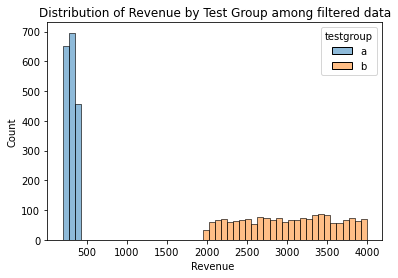

In [36]:
# гистограмма распределения доходов групп без выбросов
sns.histplot(data=df_fnn, x='revenue', hue = 'testgroup', bins = 50)
plt.xlabel('Revenue ')
plt.title('Distribution of Revenue by Test Group among filtered data')

Text(0.5, 1.0, 'Distribution of Revenue by Test Group among all data')

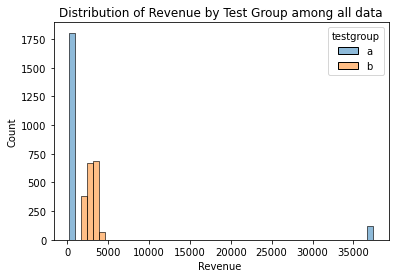

In [33]:
# гистограмма распределения доходов групп на полных данных
sns.histplot(data=df_nn, x='revenue', hue = 'testgroup', bins = 50)
plt.xlabel('Revenue ')
plt.title('Distribution of Revenue by Test Group among all data')

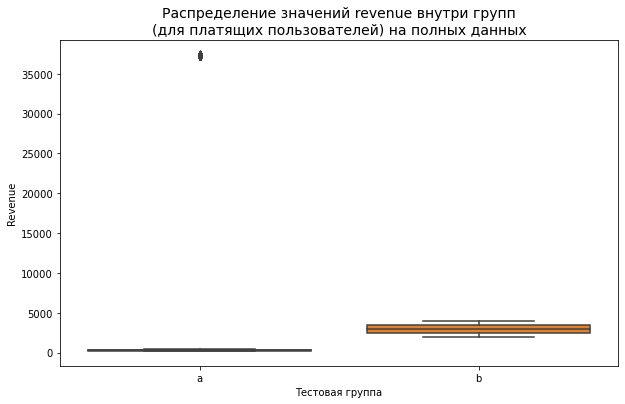

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='testgroup', y='revenue', data=df_nn) 
#взял данные платящих и с выбросами. видна та самая отличающаяся 100 юзеров в группе А

plt.title('Распределение значений revenue внутри групп\n(для платящих пользователей) на полных данных', fontsize=14)

plt.xlabel('Тестовая группа')
plt.ylabel('Revenue')

plt.show()

Таким образом, мы видим что данные выручки группы Б имеют больший разброс. 

Похоже что клиенты Б более активно вовлечены в игровой процесс финансово.

Оба распределения кажутся максимально далекими от нормального.

Осталось понять насколько эти наблюдения статистически значимы.

## 2.3 Статистические проверки значимости

Проверим данные на нормальность в строгом виде.


In [ ]:
#df_fnn - платящие без выбросов
#df_nn - платящие

In [50]:
#проверим для платящих в полном датасете

In [51]:
result = st.shapiro(df_nn['testgroup'] =='a')
alpha = 0.05

print('Распределение группы А нормальное.' if result[1] > alpha else 'Распределение группы А не является нормальным.')

Распределение группы А не является нормальным.


In [52]:
result = st.shapiro(df_nn['testgroup'] =='a')
alpha = 0.05

print('Распределение группы Б нормальное.' if result[1] > alpha else 'Распределение группы Б не является нормальным.')

Распределение группы Б не является нормальным.


Проверим данные на гомогенность дисперсии. Используем тест Левена тк данные не являются нормальными и тест Бартлетта не подходит

In [53]:
a = df_nn[df_nn['testgroup'] == 'a'].revenue
b = df_nn[df_nn['testgroup'] == 'b'].revenue


test = st.levene(a, b)


param = test.pvalue > 0.05
print('Дисперсии выборок не имеют статистически значимых отличий' if param else 'Дисперсии значимо различаются.')

Дисперсии значимо различаются.


Аналогично для платящих пользователей без выбросов


In [54]:
result = st.shapiro(df_fnn['testgroup'] =='a')
alpha = 0.05

print('Распределение группы А нормальное.' if result[1] > alpha else 'Распределение группы А не является нормальным.')

result = st.shapiro(df_fnn['testgroup'] =='a')
alpha = 0.05

print('Распределение группы Б нормальное.' if result[1] > alpha else 'Распределение группы Б не является нормальным.')

Распределение группы А не является нормальным.
Распределение группы Б не является нормальным.


In [55]:
a = df_fnn[df_fnn['testgroup'] == 'a'].revenue
b = df_fnn[df_fnn['testgroup'] == 'b'].revenue


test = st.levene(a, b)


param = test.pvalue > 0.05
print('Дисперсии выборок не имеют статистически значимых отличий' if param else 'Дисперсии значимо различаются.')

Дисперсии значимо различаются.


## 2.4 Проверка гипотез

#### Для начала проверим отличаются ли распределения выручки платящих пользователей. 
Это может подсказать как ведет себя ARPU - средняя выручка с пользователя - в первом приближении.
Смотреть на конкретно распределение выручки всех пользователей малополезно - из-за большого числа нулей.

    Гипотезы: 
- Нулевая гипотеза: распределение значений выручки с платящего пользователя контрольной и тестовой групп одинаковые.
- Альтернативная гипотеза: распределение значений выручки с платящего пользователя контрольной и тестовой групп различаются.

Ввиду отсутствия как нормальности данных так и гомогенности дисперсий мы не можем использовать t-тест.
Теоретически, мы можем прологарифмировать данные - если они будут похожи на нормальные можно взять t-тест Уэлча.

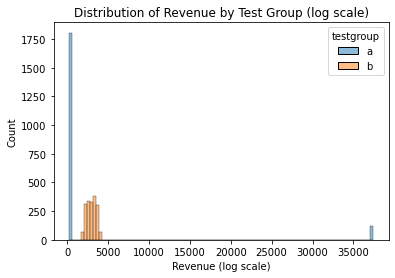

In [56]:
sns.histplot(data=df_nn, x='revenue', hue='testgroup', bins=100)
plt.xlabel('Revenue')
plt.title('Distribution of Revenue by Test Group with the outliers present')
plt.show()
#данные явно далеки от нормальных

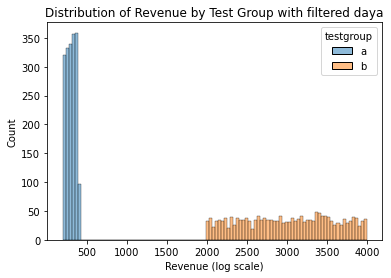

In [58]:
sns.histplot(data=df_fnn, x='revenue', hue='testgroup', bins=100)
plt.xlabel('Revenue (log scale)')
plt.title('Distribution of Revenue by Test Group with filtered daya')
plt.show()
#данные явно далеки от нормальных

В таком случае, для проверки гипотез используем критерий Уэлча для т-теста так как он позволяет сделать поправку на разницу в дисперсиях и ввиду большого числа данных к нему применима ЦПТ

In [62]:

statistic, p_value = st.ttest_ind(df_nn[df_nn['testgroup'] == 'a'].revenue, \
                         df_nn[df_nn['testgroup'] == 'b'].revenue, equal_var=False)


alpha = 0.05
print("Отвергаем нулевую гипотезу о равенстве распределений выручки" if p_value < alpha else "Не можем отвергнуть нулевую гипотезу")
statistic, p_value

Не можем отвергнуть нулевую гипотезу


(-1.644630266430084, 0.10020780398916015)

In [63]:
statistic, p_value = st.ttest_ind(df_fnn[df_fnn['testgroup'] == 'a'].revenue, \
                         df_fnn[df_fnn['testgroup'] == 'b'].revenue, equal_var=False)


alpha = 0.05
print("Отвергаем нулевую гипотезу о равенстве распределений выручки" if p_value < alpha else "Не можем отвергнуть нулевую гипотезу")
statistic, p_value

Отвергаем нулевую гипотезу о равенстве распределений выручки


(-199.3972253399533, 0.0)

Таким образом, мы не можем строго утверждать что данные без фильтра по выбросам имеют значимые отличия в распределение
В то время как данные без выбросов показывает что распределения выручки действительно имеют статзначимое отличие

### Проведем  сравнение метрик


#### 1) CR - conversion rate
посмотрим на конверсии в платящих пользователей в обоих датасетах:

- нулевая гипотеза - равенство конверсий
- альтернативная - можно с уверенностью утверждать что в группах разная конверсия

Можем применить как z-test так и Фишера - используем точный метод Фишера он более долгий но даст тот же результат на больших данных, а на малых является более применимым

In [84]:
CR = df_nn.groupby('testgroup').size() / df.groupby('testgroup').size() * 100
CR

testgroup
a    0.953969
b    0.890624
dtype: float64

In [95]:
p_value = st.fisher_exact(np.array([df.groupby('testgroup').size().values - df_nn.groupby('testgroup').size().values, df_nn.groupby('testgroup').size().values]).T)[1]
p_value
#Таким образом нулевая гипотеза о равенстве конверсий на полных данных - отклоняется

0.03531815729917575

In [94]:
CRf = df_fnn.groupby('testgroup').size()/df_filt.groupby('testgroup').size()*100
CRf

testgroup
a    0.893653
b    0.890624
dtype: float64

In [99]:
p_value = st.fisher_exact(np.array([df_filt.groupby('testgroup').size().values - df_fnn.groupby('testgroup').size().values, df_fnn.groupby('testgroup').size().values]).T)[1]
p_value 
#наоборот нет статзначимого отличия конверсия - не можем отклонить гипотезу о равенстве конверсий

0.920108418523283

#### 2) ARPU средней выручки платящего пользователя
Жалко удалять бутстрэп - применим его в качестве упражнения для изучения ARPU двух кейсов
без выбросов (df_fnn) и на более полном датасете (df_nn) платящих юзеров

Гипотезы:  
- Нулевая гипотеза: ARPPU средняя выручка с платящего пользователя одинакова в обоих группах.
- Альтернативная гипотеза: ARPPU средняя выручка с платящего пользователя  различается.

In [65]:
def two_sample_bootstrap_test(a, b, reps=10000):

    observed_diff = b.mean() - a.mean()
    
    combined = np.concatenate([a, b])
    n_a, n_b = len(a), len(b)
    
    boot_diffs = []
    for _ in range(reps):

        boot_combined = np.random.choice(combined, size=n_a + n_b, replace=True)
        boot_a = boot_combined[:n_a]
        boot_b = boot_combined[n_a:]
        boot_diffs.append(boot_b.mean() - boot_a.mean())
    

    p_value = np.mean(np.abs(boot_diffs) >= np.abs(observed_diff))
    
    return p_value, observed_diff, boot_diffs

a_paying = df_nn[df_nn['testgroup'] == 'a']['revenue']
b_paying = df_nn[df_nn['testgroup'] == 'b']['revenue']

p_value, diff, boot_diffs = two_sample_bootstrap_test(a_paying, b_paying)

print(f"ARPPU A: {a_paying.mean():.2f}, ARPPU B: {b_paying.mean():.2f}")
print(f"P-value: {p_value:.4f}")
print("Отвергаем нулевую гипотезу о равенстве ARPPU" if p_value < 0.05 else "Не получается отклонить гипотезу о равенстве ARPPU и принять альтернативу")

ARPPU A: 2664.00, ARPPU B: 3003.66
P-value: 0.1106
Не получается отклонить гипотезу о равенстве ARPPU и принять альтернативу


In [66]:

a_paying = df_fnn[df_fnn['testgroup'] == 'a']['revenue']
b_paying = df_fnn[df_fnn['testgroup'] == 'b']['revenue']

p_value, diff, boot_diffs = two_sample_bootstrap_test(a_paying, b_paying)

print(f"ARPPU A: {a_paying.mean():.2f}, ARPPU B: {b_paying.mean():.2f}")
print(f"P-value: {p_value:.4f}")
print("Отвергаем нулевую гипотезу о равенстве ARPPU" if p_value < 0.05 else "Не получается отклонить гипотезу о равенстве ARPPU и принять альтернативу")

ARPPU A: 302.46, ARPPU B: 3003.66
P-value: 0.0000
Отвергаем нулевую гипотезу о равенстве ARPPU


Аналогично, мы не можем ничего сказать с уверенностью о нефильтрованных данных - в этом кейсе нулевая гипотеза о равенстве метрик не может быть отклонена

Только убрав аномальных 123 юзера мы можем засвидетельствовать статзначимые отличия двух групп

## 2.5 Результаты A/B теста
В ходе обработки данных было решено рассмотреть два случая:
1-й убрать 123 аномальных значений, которые могут быть результатом ошибки сбора данных либо деления на группы и негативно влиять на А/Б тестирование.
2-й оставить полные данные

В обоих случаях данные не прошли тест ни на нормальность, ни на равенство дисперсий. 
в качестве метрик для сравнения были взяты CR, ARPU, ARPPU
зафиксировано статзначимое отличие в конверсии для полных данных с помощью теста Фишера
таковое отличие отсутствует для фильтрованных данных

критерий Уэлча позволил обойти ограничения данных и показать статзначимое отличие средней выручки платящего пользователя для фильтрованных данных. Аналогичное исследование не дало возможности отклонить гипотезу о равенстве ARPU для полных данных.

Так же вышло и с ARPPU

По итогу проверок, наше исследование показало что разница как в ARPU так и в ARPPU не может быть случайной для фильтрованных групп
К тому же мы убедились что и распределения значения выручки платящих пользователей в группах контроля и теста имеют статистическую значимость.

Таким образом, исходя из текущих данных, есть основания утверждать, что тестирование прошло успешно и feature стоит внедрять дальше. Однако, стоит исследовать причину попадания столь разных групп в полные данные - увы с ними мы не можем быть столь уверены.

## 3. Анализ метрик события


В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

 Сразу хочется обратиться внимание следующие метрики которые стоит отслеживать в целом:
 
 Метрики роста 
- DAU/MAU - метрика ежедневно активных пользователей покажет насколько заметным является всплеск активности во время ивента в сравнении с обычными днями (пример: события в MLBB), в то время как метрика ежемесячно активных пользователей поможет сравнивать ивенты между собой - особенно если они являются длительными (пример: главы и сезоны в Фортнайте);

Метрики продукта:
- Stickiness rate = DAU/MAU - удобная индикация, помогает быстро понять не просели ли предыдущие метрики;
- Session Length - продолжительность мобильной сессии - помогает понять насколько меняется время в продукте. Команда продукта стимулирует пользователей к покупкам и при прочих равных большее время в продукте приводит к более частым покупкам;
- Activation Rate - доля пользователей совершающих некоторые целевые действия. Допустим доходят до какого-то уровня трат что бы получить дополнительный бонус;

Можно предложить несколько дополнительных метрик для усложненных событий:

- Crash Rate - доля сессий заканчивающихся вылетом из приложения. В нагруженной, требующей от пользователя усилий сессии - что-то может пойти не так. Надо держать руку на пульсе. Возможно под трудные события каким-то устройствам не хватит оптимизации.

- Churn Rate - метрика оттока - покажет не слишком ли хардкорны новые механики для нашей целевой аудитории

Возможно, стоит изучить являются ли последние метрики значимыми на больших данных и моделях